# 🎯 CTR Prediction — Ad Click-Through Rate
**Metric:** Normalized Cross-Entropy (NCE) — lower is better (< 1.0 beats baseline)

**Strategy:**
- Feature engineering 
- Frequency encoding 
- Time-based CV split
- Ensemble: LightGBM + XGBoost + CatBoost
- Calibration ด้วย Isotonic Regression

In [ ]:
# ── Install ──────────────────────────────────────────────────────────────────
!pip install lightgbm xgboost catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import log_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
print('All libraries loaded ✅')

All libraries loaded ✅


## 1. Load Data

In [ ]:
unzip = True
if unzip:
    !unzip -q the-ad-ecosystem-and-ctr-prediction.zip

In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train['clicked'] = train['clicked'].astype(int)
print(f"Train CTR (base_ctr): {train['clicked'].mean():.4f}")
train.head(2)

Train: (374590, 28)  |  Test: (125410, 27)
Train CTR (base_ctr): 0.3069


,impression_id,user_id,timestamp,hour,day_of_week,banner_pos,device_type,device_model,device_conn_type,is_app,...,ad_quality_score,C1,C15,C16,C21,user_depth,user_segment,historical_user_ctr,creative_size,clicked
0,imp_00000000,u_7d963b,2024-01-02 12:00:00,12,Sat,0,Desktop,Generic_32,WiFi,False,...,0.000,1,1,1,5,1,casual,0.2979,300x600,1
1,imp_00000001,u_c83eac,2024-01-13 03:00:00,3,Thu,0,Tablet,Generic_1,WiFi,True,...,0.235,6,1,0,0,4,ad_blind,0.2439,728x90,0


## 2. Evaluation Metric

In [ ]:
def normalized_cross_entropy(y_true: np.ndarray,
                             y_pred: np.ndarray,
                             base_ctr: float | None = None) -> float:
    """
    NCE = model_logloss / baseline_logloss
    Baseline predicts the training set CTR for every impression.
    Lower is better; < 1.0 means the model beats the naive baseline.
    """
    if base_ctr is None:
        base_ctr = float(np.mean(y_true))
    baseline_pred   = np.full_like(y_pred, base_ctr)
    model_logloss   = log_loss(y_true, y_pred)
    baseline_logloss = log_loss(y_true, baseline_pred)
    return model_logloss / baseline_logloss

BASE_CTR = train['clicked'].mean()
print(f'Base CTR = {BASE_CTR:.4f}')

Base CTR = 0.3069


## 3. Feature Engineering

In [ ]:
train.head()

,impression_id,user_id,timestamp,hour,day_of_week,banner_pos,device_type,device_model,device_conn_type,is_app,...,ad_quality_score,C1,C15,C16,C21,user_depth,user_segment,historical_user_ctr,creative_size,clicked
0,imp_00000000,u_7d963b,2024-01-02 12:00:00,12,Sat,0,Desktop,Generic_32,WiFi,False,...,0.0000,1,1,1,5,1,casual,0.2979,300x600,1
1,imp_00000001,u_c83eac,2024-01-13 03:00:00,3,Thu,0,Tablet,Generic_1,WiFi,True,...,0.2350,6,1,0,0,4,ad_blind,0.2439,728x90,0
2,imp_00000002,u_df0989,2024-01-10 23:00:00,23,Mon,0,Mobile,iPhone13,WiFi,True,...,0.2623,3,1,0,3,2,casual,0.2669,728x90,0
3,imp_00000003,u_d56298,2024-01-11 16:00:00,16,Wed,0,Mobile,iPhone12,WiFi,True,...,0.1568,1,4,0,1,8,casual,0.2802,300x250,0
4,imp_00000004,u_d526fc,2024-01-14 19:00:00,19,Fri,1,Desktop,Generic_27,WiFi,False,...,0.1977,6,1,3,1,1,casual,0.2834,728x90,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374590 entries, 0 to 374589
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   impression_id        374590 non-null  object 
 1   user_id              374590 non-null  object 
 2   timestamp            374590 non-null  object 
 3   hour                 374590 non-null  int64  
 4   day_of_week          374590 non-null  object 
 5   banner_pos           374590 non-null  int64  
 6   device_type          374590 non-null  object 
 7   device_model         374590 non-null  object 
 8   device_conn_type     374590 non-null  object 
 9   is_app               374590 non-null  bool   
 10  site_id              204372 non-null  object 
 11  site_domain          204372 non-null  object 
 12  app_id               170218 non-null  object 
 13  app_domain           170218 non-null  object 
 14  site_category        374590 non-null  object 
 15  ad_id            

In [ ]:
train.describe()

,hour,banner_pos,ad_quality_score,C1,C15,C16,C21,user_depth,historical_user_ctr,clicked
count,374590.000000,374590.000000,374590.000000,374590.000000,374590.000000,374590.000000,374590.000000,374590.000000,374590.000000,374590.000000
mean,13.761934,1.352836,0.229372,3.001116,2.002066,2.501308,3.501337,3.154123,0.280787,0.306888
std,5.874729,2.011102,0.127695,2.002332,1.413313,1.706671,2.290904,2.575129,0.069364,0.461203
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,9.000000,0.000000,0.136200,1.000000,1.000000,1.000000,2.000000,1.000000,0.245900,0.000000
50%,14.000000,1.000000,0.237200,3.000000,2.000000,3.000000,3.000000,2.000000,0.280000,0.000000
75%,19.000000,1.000000,0.316400,5.000000,3.000000,4.000000,6.000000,4.000000,0.296175,1.000000
max,23.000000,7.000000,1.000000,6.000000,4.000000,5.000000,7.000000,27.000000,1.000000,1.000000


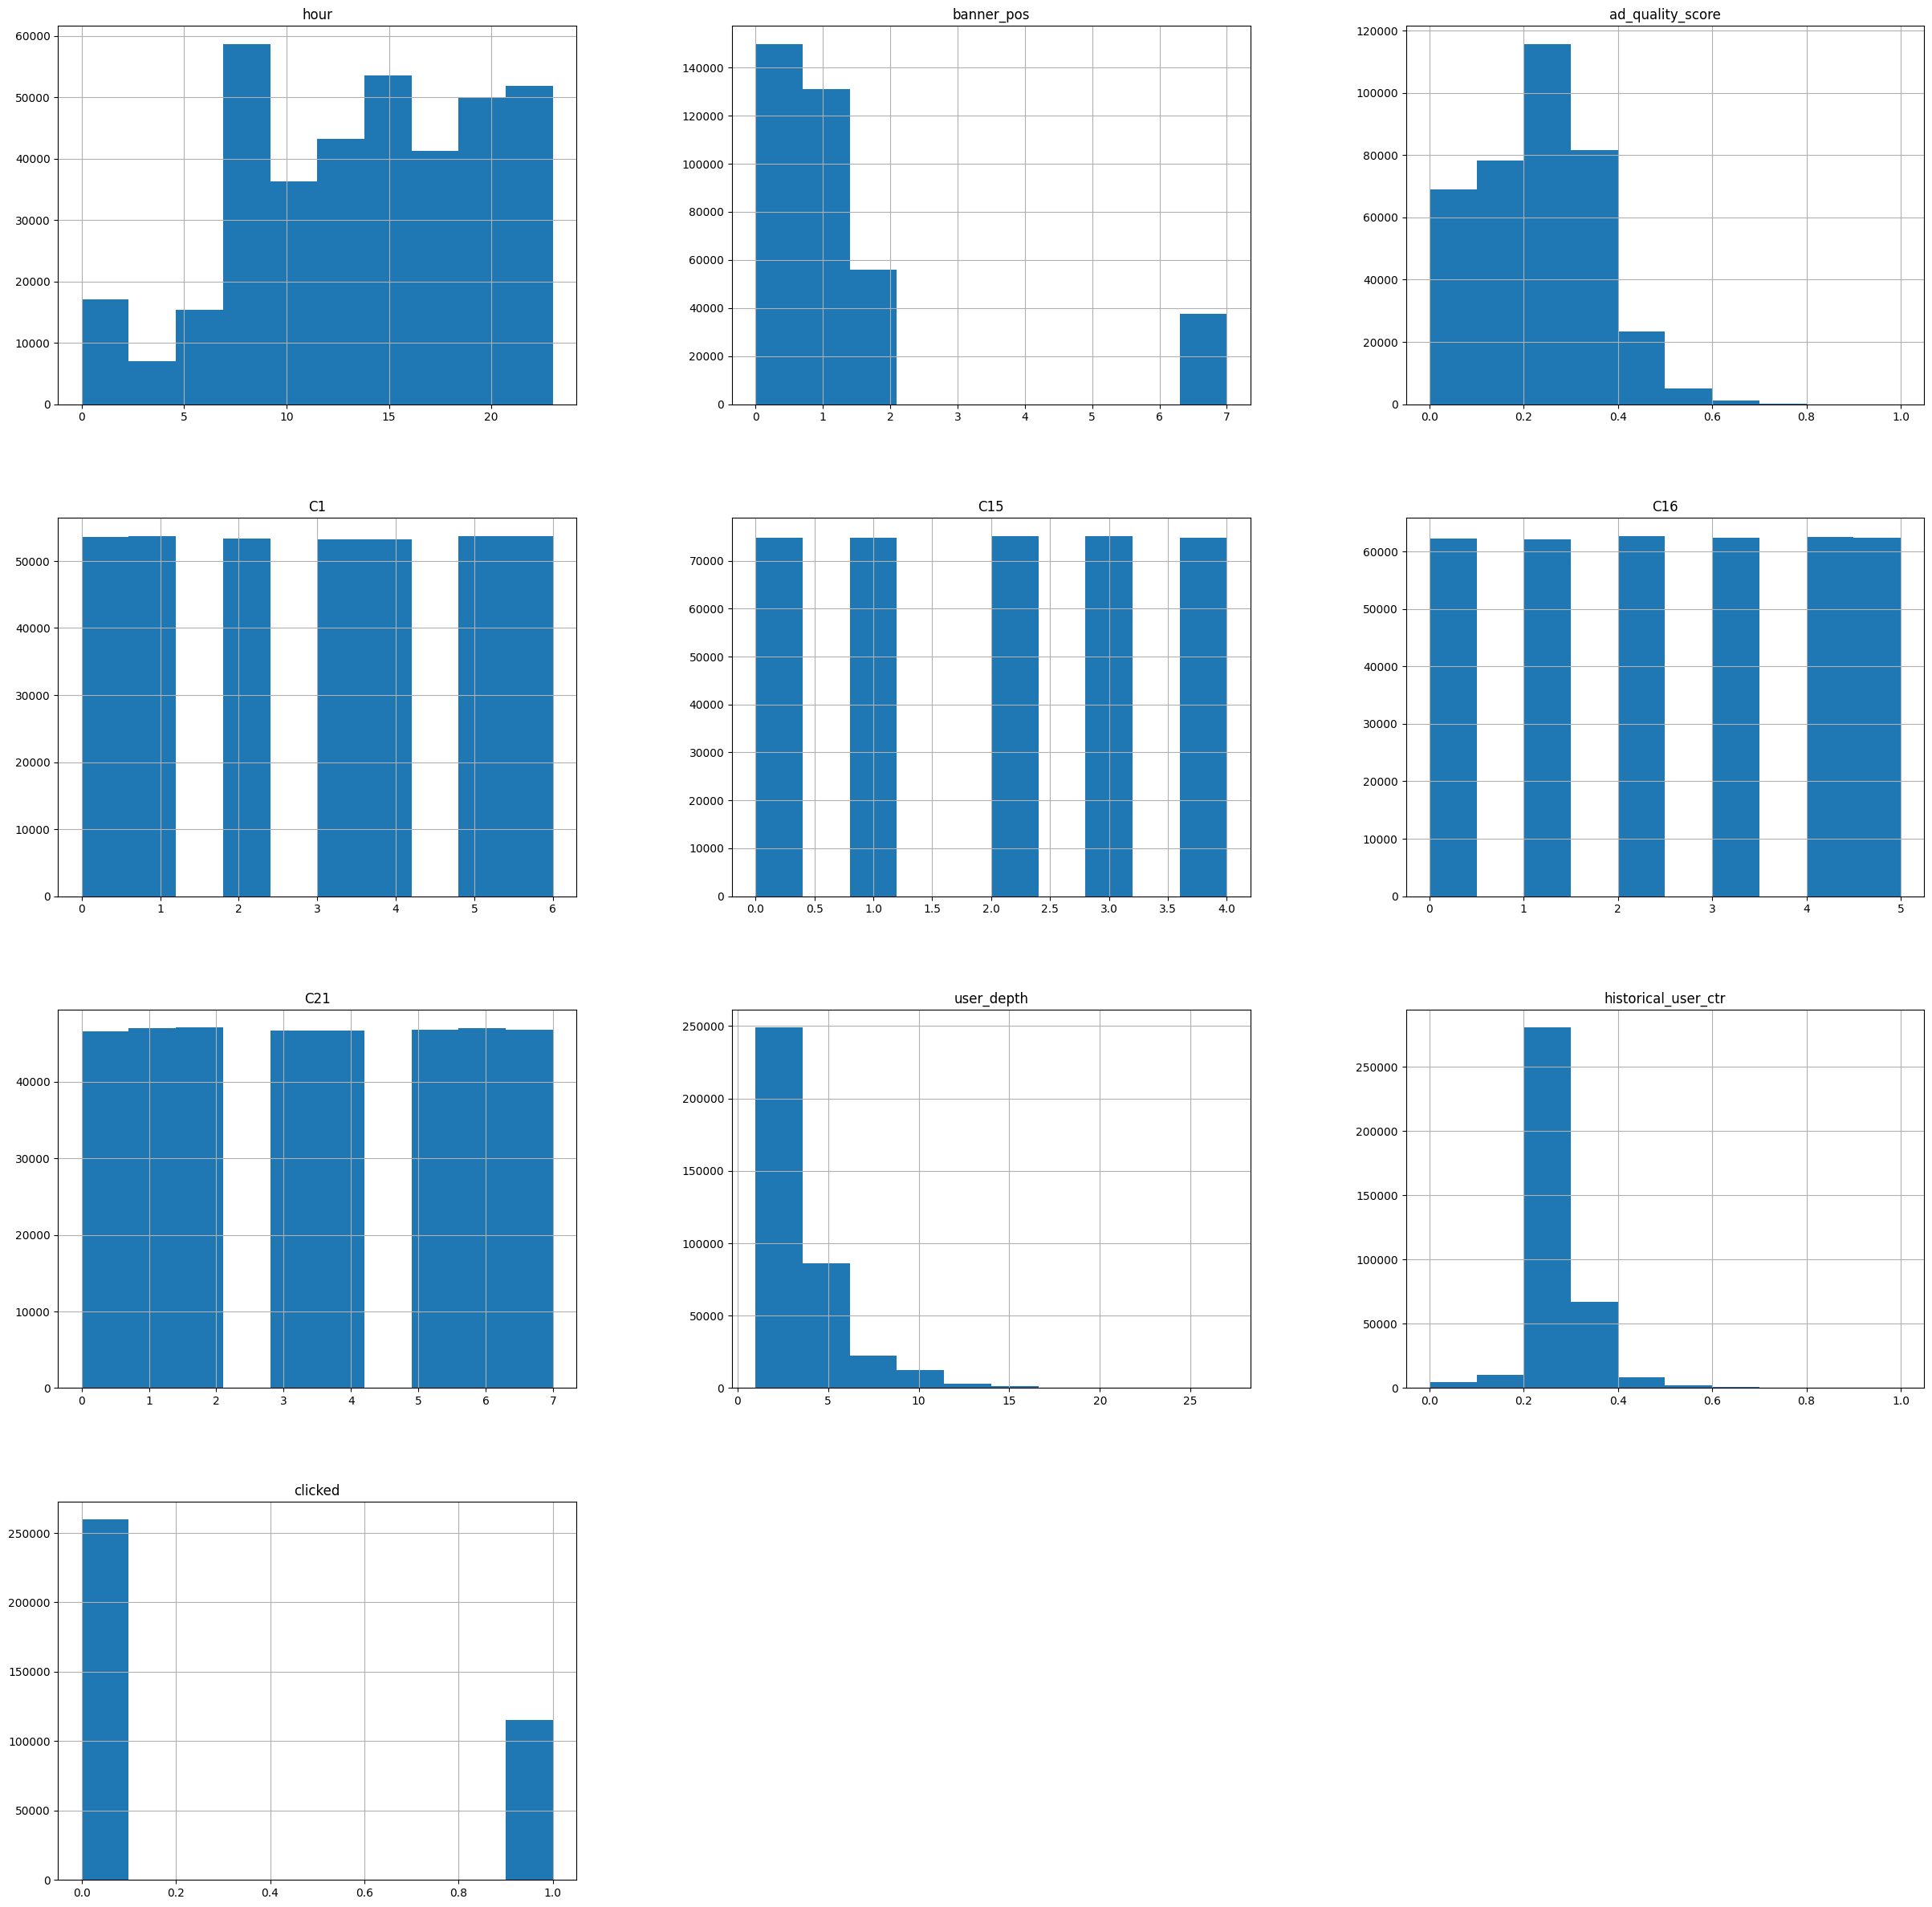

In [ ]:
import matplotlib.pyplot as plt
train.hist(figsize = (30, 30))
plt.show()

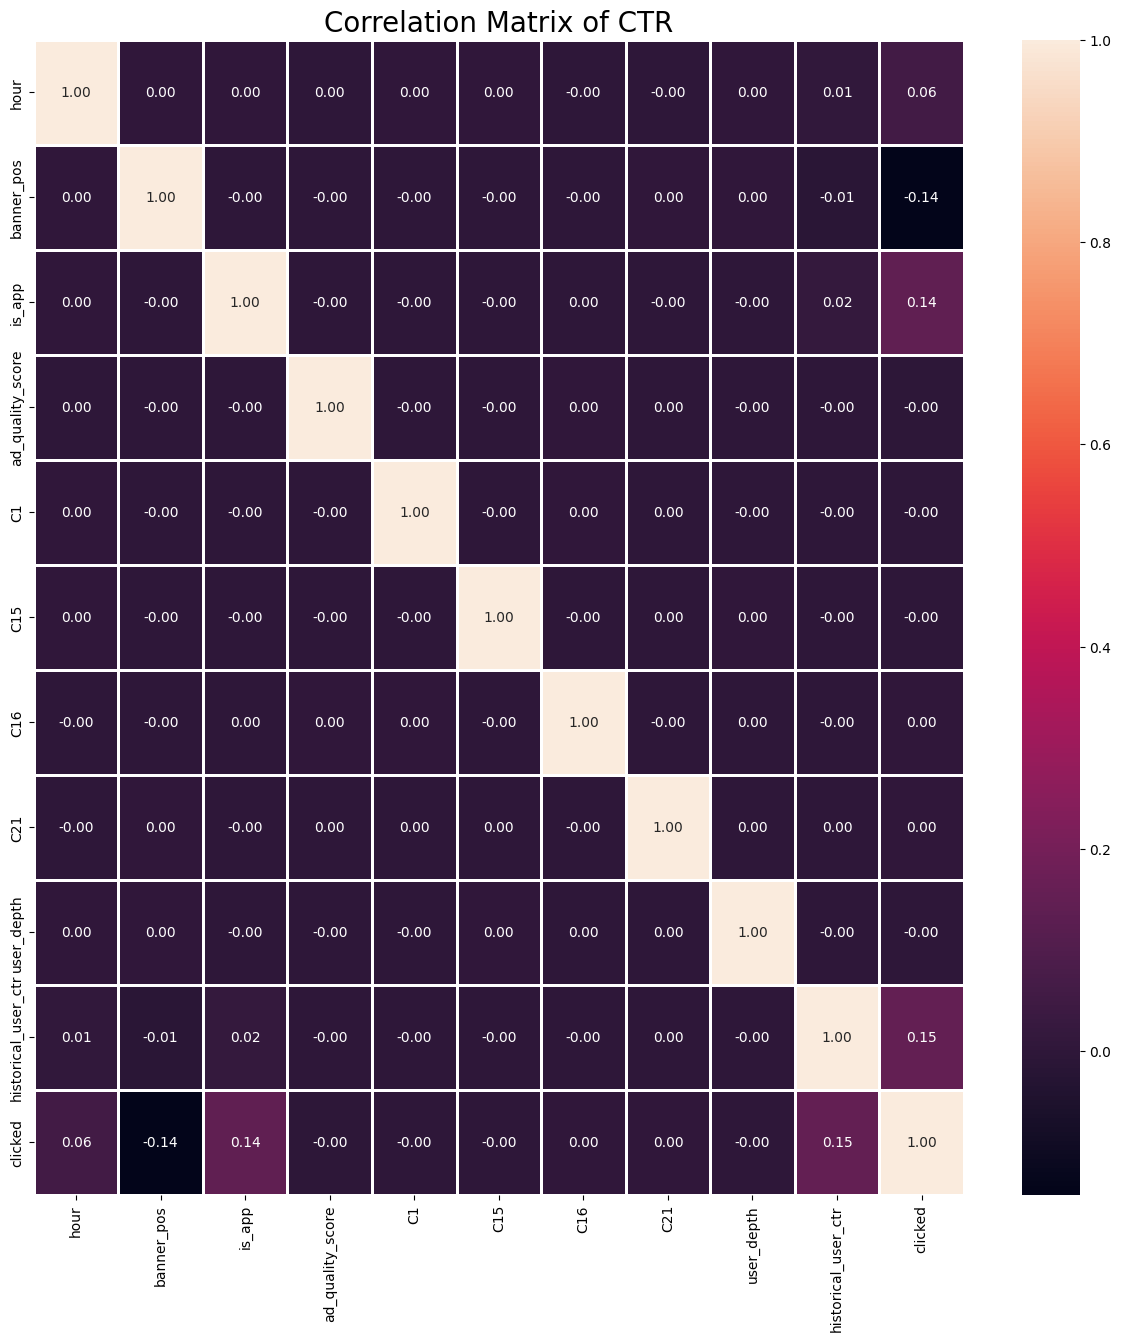

In [ ]:
import seaborn as sns

# Correlation Matrix
corr_matrix = train.corr(numeric_only=True)
plt.figure(figsize = (15, 15))
cm = sns.heatmap(corr_matrix,
               linewidths = 1,
               annot = True,
               fmt = ".2f")
plt.title("Correlation Matrix of CTR", fontsize = 20)
plt.show()

In [ ]:
def feature_engineering(df, train_df=None, is_train=True):
    df = df.copy()

    # ── Parse timestamp ──────────────────────────────────────────────────────
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['week']      = df['timestamp'].dt.isocalendar().week.astype(int)
    df['day']       = df['timestamp'].dt.day
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['is_weekend'] = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)
    df['is_primetime'] = df['hour'].between(18, 22).astype(int)
    df['is_morning']   = df['hour'].between(6, 11).astype(int)

    # ── Null flags (nulls carry semantic meaning!) ────────────────────────────
    df['is_app']    = df['is_app'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)
    df['has_site']  = df['site_id'].notna().astype(int)
    df['has_app']   = df['app_id'].notna().astype(int)

    # ── Frequency encoding for high-cardinality columns ───────────────────────
    ref = train_df if train_df is not None else df
    high_card_cols = ['user_id', 'ad_id', 'ad_campaign_id', 'publisher_id',
                      'site_id', 'app_id', 'site_domain', 'app_domain', 'device_model']
    for col in high_card_cols:
        freq_map = ref[col].value_counts(normalize=True).to_dict()
        df[f'{col}_freq'] = df[col].map(freq_map).fillna(0)

    # ── Label encode low-cardinality categoricals ─────────────────────────────
    cat_cols = ['device_type', 'device_conn_type', 'banner_pos',
                'site_category', 'user_segment',
                'creative_size', 'C1', 'C15', 'C16', 'C21',
                'day_of_week']
    for col in cat_cols:
        df[col] = df[col].astype(str).fillna('missing')
        if is_train:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
        else:
            # Map using training vocab (unseen → -1)
            ref_vals = ref[col].astype(str).fillna('missing').unique()
            val_map  = {v: i for i, v in enumerate(sorted(ref_vals))}
            df[col]  = df[col].map(val_map).fillna(-1).astype(int)

    # ── Interaction features ──────────────────────────────────────────────────
    df['user_depth_log']   = np.log1p(df['user_depth'])
    df['ctr_x_quality']    = df['historical_user_ctr'] * df['ad_quality_score'].fillna(0)
    df['ctr_x_depth']      = df['historical_user_ctr'] * np.log1p(df['user_depth'])

    return df

print('Building features...')
train_fe = feature_engineering(train, train_df=train, is_train=True)
test_fe  = feature_engineering(test,  train_df=train, is_train=False)
print('Done ✅')

Building features...
Done ✅


In [ ]:
# ── Define feature columns ───────────────────────────────────────────────────
DROP_COLS = ['impression_id', 'user_id', 'timestamp', 'clicked',
             'ad_id', 'ad_campaign_id', 'publisher_id',
             'site_id', 'app_id', 'site_domain', 'app_domain', 'device_model', 'C1', 'C15', 'C16', 'C21']

FEATURE_COLS = [c for c in train_fe.columns if c not in DROP_COLS]
print(f'Using {len(FEATURE_COLS)} features')
print(FEATURE_COLS)

Using 33 features
['hour', 'day_of_week', 'banner_pos', 'device_type', 'device_conn_type', 'is_app', 'site_category', 'ad_quality_score', 'user_depth', 'user_segment', 'historical_user_ctr', 'creative_size', 'week', 'day', 'hour_sin', 'hour_cos', 'is_weekend', 'is_primetime', 'is_morning', 'has_site', 'has_app', 'user_id_freq', 'ad_id_freq', 'ad_campaign_id_freq', 'publisher_id_freq', 'site_id_freq', 'app_id_freq', 'site_domain_freq', 'app_domain_freq', 'device_model_freq', 'user_depth_log', 'ctr_x_quality', 'ctr_x_depth']


Top Correlations with 'clicked':
clicked                1.000000
historical_user_ctr    0.149266
has_app                0.143095
is_app                 0.143095
app_domain_freq        0.122430
device_type            0.095734
app_id_freq            0.091247
user_segment           0.078380
device_model_freq      0.074812
ctr_x_depth            0.072239
is_primetime           0.070701
hour                   0.057642
ctr_x_quality          0.055041
is_weekend             0.037369
ad_id_freq             0.013700
hour_cos               0.013486
creative_size         -0.000194
publisher_id_freq     -0.000399
site_category         -0.000883
user_depth_log        -0.001109
day                   -0.001272
user_depth            -0.001381
week                  -0.001760
user_id_freq          -0.002947
ad_campaign_id_freq   -0.002964
ad_quality_score      -0.004654
day_of_week           -0.007627
is_morning            -0.042082
hour_sin              -0.059648
device_conn_type      -0.076667
site_id

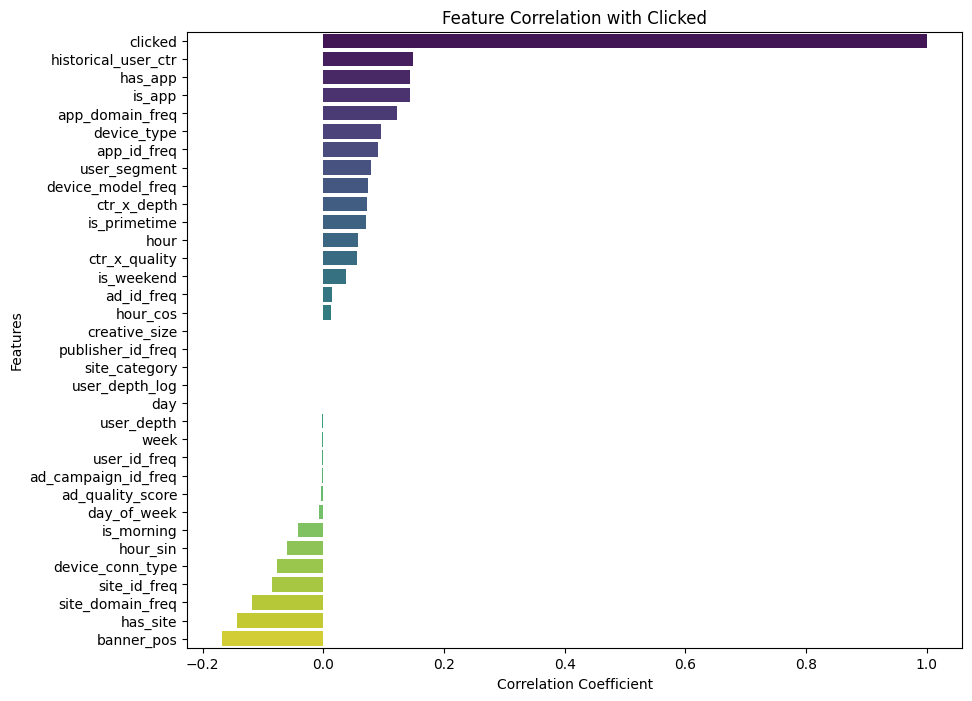

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation with target
correlations = train_fe[FEATURE_COLS + ['clicked']].corr()['clicked'].sort_values(ascending=False)

# Display top correlations
print("Top Correlations with 'clicked':")
print(correlations)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Feature Correlation with Clicked')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

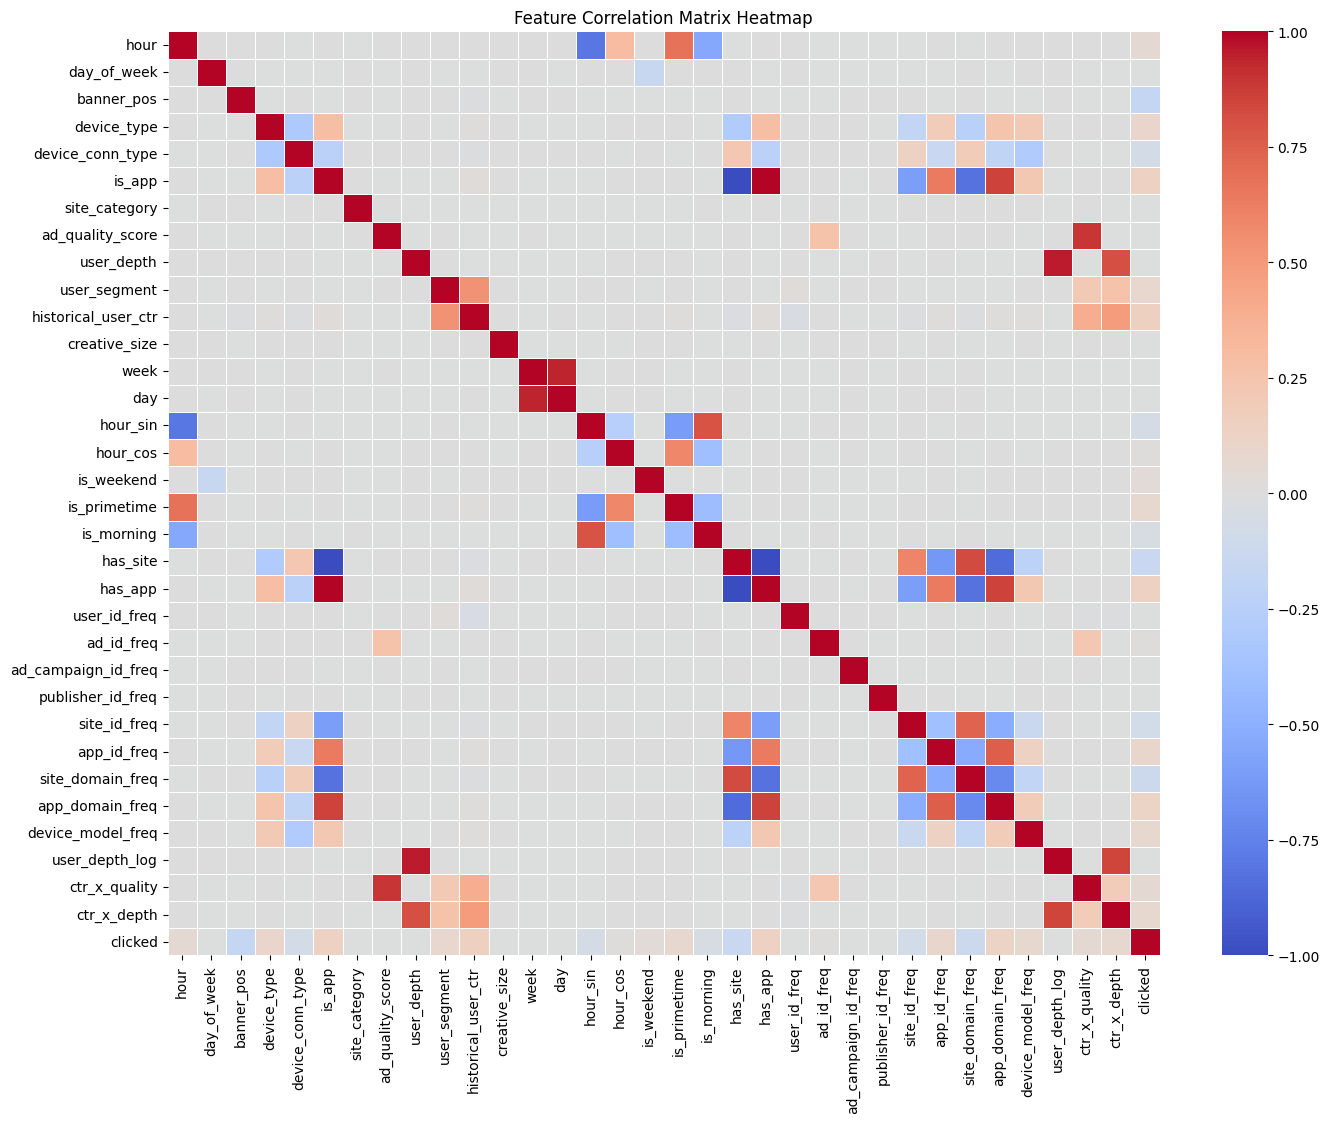

Top correlated pairs (excluding self-correlation):
user_depth        user_depth_log      0.954679
user_depth_log    user_depth          0.954679
week              day                 0.943728
day               week                0.943728
ctr_x_quality     ad_quality_score    0.891058
ad_quality_score  ctr_x_quality       0.891058
has_site          app_domain_freq     0.854418
app_domain_freq   has_site            0.854418
                  is_app              0.854418
has_app           app_domain_freq     0.854418
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate full correlation matrix
corr_matrix = train_fe[FEATURE_COLS + ['clicked']].corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.show()

# Display top pairs of correlated features
print("Top correlated pairs (excluding self-correlation):")
corr_unstacked = corr_matrix.abs().unstack().sort_values(ascending=False)
# Filtering out values of 1.0 (self-correlation)
print(corr_unstacked[corr_unstacked < 0.9999].head(10))

## 4. Time-Based Cross-Validation Split


In [ ]:
# Train on week 1-2, validate on week 3
mask_val = train_fe['week'] == train_fe['week'].max()
tr = train_fe[~mask_val].reset_index(drop=True)
vl = train_fe[mask_val].reset_index(drop=True)

X_tr, y_tr = tr[FEATURE_COLS], tr['clicked']
X_vl, y_vl = vl[FEATURE_COLS], vl['clicked']
X_test      = test_fe[FEATURE_COLS]

print(f'Train fold: {X_tr.shape}  |  Val fold: {X_vl.shape}')
print(f'Val week distribution: {vl["week"].value_counts().to_dict()}')

Train fold: (250046, 33)  |  Val fold: (124544, 33)
Val week distribution: {3: 124544}


## 5. Train Models

In [ ]:
# ── LightGBM ─────────────────────────────────────────────────────────────────
lgb_params = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'learning_rate':    0.025,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples': 100,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'lambda_l1':        0.3,
    'lambda_l2':        0.4,
    'verbose':          -1,
    'seed':             SEED,
}

lgb_train = lgb.Dataset(X_tr, label=y_tr)
lgb_val   = lgb.Dataset(X_vl, label=y_vl, reference=lgb_train)

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_val_pred  = lgb_model.predict(X_vl)
lgb_test_pred = lgb_model.predict(X_test)
print(f'\n🌿 LightGBM Val NCE: {normalized_cross_entropy(y_vl, lgb_val_pred, BASE_CTR):.4f}')

[100]	training's binary_logloss: 0.514151	valid_1's binary_logloss: 0.514893
[200]	training's binary_logloss: 0.505518	valid_1's binary_logloss: 0.509604
[300]	training's binary_logloss: 0.501331	valid_1's binary_logloss: 0.509116

🌿 LightGBM Val NCE: 0.8278


In [ ]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      'logloss',
    'learning_rate':    0.03,
    'max_depth':        7,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 50,
    'reg_alpha':        0.01,
    'reg_lambda':       0.01,
    'seed':             SEED,
    'verbosity':        0,
}

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_vl, label=y_vl)
dtest  = xgb.DMatrix(X_test)

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=5000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=100,
    verbose_eval=100
)

xgb_val_pred  = xgb_model.predict(dval)
xgb_test_pred = xgb_model.predict(dtest)
print(f'\n⚡ XGBoost Val NCE: {normalized_cross_entropy(y_vl, xgb_val_pred, BASE_CTR):.4f}')

[0]	train-logloss:0.61196	val-logloss:0.60965
[100]	train-logloss:0.51083	val-logloss:0.51250
[200]	train-logloss:0.50455	val-logloss:0.50931
[300]	train-logloss:0.50105	val-logloss:0.50918
[349]	train-logloss:0.49955	val-logloss:0.50923

⚡ XGBoost Val NCE: 0.8281


In [ ]:
# ── CatBoost ──────────────────────────────────────────────────────────────────
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    min_data_in_leaf=50,
    subsample=0.8,
    loss_function='Logloss',
    eval_metric='Logloss',
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=50
)

cat_model.fit(
    X_tr, y_tr,
    eval_set=(X_vl, y_vl),
    use_best_model=True
)

cat_val_pred  = cat_model.predict_proba(X_vl)[:, 1]
cat_test_pred = cat_model.predict_proba(X_test)[:, 1]
print(f'\n🐱 CatBoost Val NCE: {normalized_cross_entropy(y_vl, cat_val_pred, BASE_CTR):.4f}')

0:	learn: 0.6745264	test: 0.6744513	best: 0.6744513 (0)	total: 143ms	remaining: 2m 23s
100:	learn: 0.5105730	test: 0.5096259	best: 0.5096259 (100)	total: 7.68s	remaining: 1m 8s
200:	learn: 0.5075705	test: 0.5085857	best: 0.5085817 (196)	total: 16.6s	remaining: 1m 6s
300:	learn: 0.5048946	test: 0.5084802	best: 0.5084497 (273)	total: 25.3s	remaining: 58.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5084497358
bestIteration = 273

Shrink model to first 274 iterations.

🐱 CatBoost Val NCE: 0.8268


## 6. Ensemble + Calibration

In [ ]:
# ── Weighted ensemble (ปรับ weights ตาม val NCE) ──────────────────────────────
lgb_nce = normalized_cross_entropy(y_vl, lgb_val_pred, BASE_CTR)
xgb_nce = normalized_cross_entropy(y_vl, xgb_val_pred, BASE_CTR)
cat_nce = normalized_cross_entropy(y_vl, cat_val_pred, BASE_CTR)

# Weight = 1/NCE (lower NCE → higher weight)
nce_scores = np.array([lgb_nce, xgb_nce, cat_nce])
weights    = (1 / nce_scores) / (1 / nce_scores).sum()
print(f'Weights → LGB: {weights[0]:.3f}  XGB: {weights[1]:.3f}  CAT: {weights[2]:.3f}')

ens_val_pred  = (weights[0] * lgb_val_pred +
                 weights[1] * xgb_val_pred +
                 weights[2] * cat_val_pred)

ens_test_pred = (weights[0] * lgb_test_pred +
                 weights[1] * xgb_test_pred +
                 weights[2] * cat_test_pred)

print(f'\n🔗 Ensemble Val NCE: {normalized_cross_entropy(y_vl, ens_val_pred, BASE_CTR):.4f}')

Weights → LGB: 0.333  XGB: 0.333  CAT: 0.334

🔗 Ensemble Val NCE: 0.8271


In [ ]:
# ── Isotonic Regression Calibration ──────────────────────────────────────────
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(ens_val_pred, y_vl)

cal_val_pred  = iso_reg.predict(ens_val_pred)
cal_test_pred = iso_reg.predict(ens_test_pred)

print(f'📊 After Calibration Val NCE: {normalized_cross_entropy(y_vl, cal_val_pred, BASE_CTR):.4f}')
print(f'Prediction range: [{cal_test_pred.min():.4f}, {cal_test_pred.max():.4f}]')

📊 After Calibration Val NCE: 0.8254
Prediction range: [0.0000, 1.0000]


## 7. Summary

In [ ]:
print('=' * 50)
print('        FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'  LightGBM   NCE: {lgb_nce:.4f}')
print(f'  XGBoost    NCE: {xgb_nce:.4f}')
print(f'  CatBoost   NCE: {cat_nce:.4f}')
print(f'  Ensemble   NCE: {normalized_cross_entropy(y_vl, ens_val_pred, BASE_CTR):.4f}')
print(f'  Calibrated NCE: {normalized_cross_entropy(y_vl, cal_val_pred, BASE_CTR):.4f}')
print('=' * 50)
print('NCE < 1.0 = beats baseline ✅')

        FINAL RESULTS SUMMARY
  LightGBM   NCE: 0.8278
  XGBoost    NCE: 0.8281
  CatBoost   NCE: 0.8268
  Ensemble   NCE: 0.8271
  Calibrated NCE: 0.8254
NCE < 1.0 = beats baseline ✅


## 8. Create Submission

In [ ]:
submission = pd.DataFrame({
    'impression_id': test['impression_id'],
    'clicked': cal_test_pred
})

# Verify matches sample_submission order
sub_order = pd.read_csv('sample_submission.csv')['impression_id']
submission = submission.set_index('impression_id').loc[sub_order].reset_index()

submission.to_csv('submission.csv', index=False)
print(f'Saved submission.csv — {len(submission)} rows')
print(f'Probability stats:')
print(submission['clicked'].describe())
submission.head(10)

Saved submission.csv — 125410 rows
Probability stats:
count    125410.000000
mean          0.170264
std           0.145223
min           0.000000
25%           0.064254
50%           0.132287
75%           0.228113
max           1.000000
Name: clicked, dtype: float64


,impression_id,clicked
0,imp_00000008,0.226489
1,imp_00000009,0.003446
2,imp_00000013,0.064254
3,imp_00000017,0.228113
4,imp_00000023,0.183241
5,imp_00000025,0.089562
6,imp_00000031,0.226489
7,imp_00000032,0.102831
8,imp_00000035,0.447059
9,imp_00000036,0.016706
